device: cuda
GPU Name: NVIDIA L40S
Allocated: 0.0 GB
Seed set to: 2026


[CLF] Epoch 1/5: 100%|██████████| 938/938 [00:06<00:00, 151.90it/s, loss=0.0751]


[CLF] Epoch 1: loss=0.0751 | test_acc=98.66%


[CLF] Epoch 2/5: 100%|██████████| 938/938 [00:05<00:00, 158.43it/s, loss=0.0476]


[CLF] Epoch 2: loss=0.0476 | test_acc=99.20%


...

[CLF] Epoch 3: loss=0.0507 | test_acc=99.03%


[CLF] Epoch 4/5: 100%|██████████| 938/938 [00:05<00:00, 161.64it/s, loss=0.0348]


[CLF] Epoch 4: loss=0.0348 | test_acc=99.32%


[CLF] Epoch 5/5: 100%|██████████| 938/938 [00:05<00:00, 157.75it/s, loss=0.0245]


[CLF] Epoch 5: loss=0.0245 | test_acc=99.24%
saved: classifier_01_norm.pt


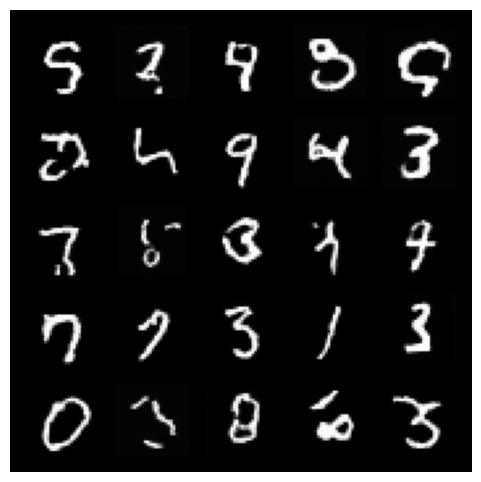

preds: [5, 3, 4, 5, 0, 2, 4, 9, 4, 3, 7, 5, 3, 4, 7, 7, 7, 3, 1, 3, 0, 3, 2, 6, 3]
confidences: [0.9993, 0.9031, 0.5835, 0.7997, 0.9423, 0.9634, 0.9491, 0.9998, 1.0, 1.0, 1.0, 0.9995, 0.9957, 0.7502, 0.9492, 1.0, 0.9964, 1.0, 1.0, 1.0, 1.0, 0.9978, 0.9566, 0.9291, 1.0]


In [1]:
# File: 02_train_classifier.ipynb
# Paste each cell into a notebook cell, or save as a .py script and run with cell support.

#
import os
import torch

from common import device, print_device, set_seed
from classifier_lib import (
    MNISTCNN,
    get_classifier_loaders,
    train_classifier,
    save_classifier_checkpoint,
    load_classifier_checkpoint,
    classify_and_show_raw,
)

print_device()

#
SEED = 2026
set_seed(SEED)

ROOT = "./data"
BATCH_SIZE = 64
CLF_EPOCHS = 5

# Keep this equal to the space the classifier notebook actually used.
INPUT_SPACE = "01_norm"      # "01_norm" or "01_raw"
CLF_CKPT_PATH = f"classifier_{INPUT_SPACE}.pt"

#
train_ds, test_ds, train_loader, test_loader = get_classifier_loaders(
    root=ROOT,
    batch_size=BATCH_SIZE,
    input_space=INPUT_SPACE,
)

clf = MNISTCNN().to(device)

#
clf = train_classifier(
    model=clf,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=CLF_EPOCHS,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
)

#
save_classifier_checkpoint(
    path=CLF_CKPT_PATH,
    model=clf,
    input_space=INPUT_SPACE,
)
print("saved:", CLF_CKPT_PATH)

#
# Optional: load unconditional DDPM samples and classify them, preserving the old workflow.
DDPM_SAMPLES_PATH = "./ddpm_samples_raw_M.pt"   # change if you want identity samples instead

if os.path.exists(DDPM_SAMPLES_PATH):
    ddpm_samples_raw = torch.load(DDPM_SAMPLES_PATH, map_location="cpu")
    clf_loaded, clf_cfg, _ = load_classifier_checkpoint(CLF_CKPT_PATH, device=device)
    _ = classify_and_show_raw(
        model=clf_loaded,
        x_raw_m11=ddpm_samples_raw[:25],
        input_space=clf_cfg["input_space"],
        mnist_mean=clf_cfg["mnist_mean"],
        mnist_std=clf_cfg["mnist_std"],
        nrow=5,
    )
else:
    print("No DDPM samples file found at:", DDPM_SAMPLES_PATH)